Feature Extraction and Classification with MLP

## Table of Contents

- [Import libraries and Custom Classes](#import-libraries-and-custom-classes)
- [Load and Prepare Dataset](#load-and-prepare-dataset)
    - [One-hot encoding the data](#one-hot-encoding-the-labels)
    - [Sample image](#sample-image)
- [Create Train-Validation Set](#create-train-validation-set)
- [Helper Functions](#helper-functions)
- [3.1 Train Autoencoder](#31-train-autoencoder)
    - [3.1.a Hidden Layer Neurons](#31a-hidden-layer-neurons)
    - [3.1.b Model Architecture](#31b-model-architecture)
    - [3.1.c ReLU](#31c-relu)
    - [3.1.d Learning Rate](#31d-learning-rate)
    - [3.1.e Batch Gradient Descent](#31e-batch-gradient-descent)
    - [Best Model](#best-model)
    - [3.1.f Images with the largest and smallest loss](#31f-images-with-the-largest-and-smallest-loss)
- [3.2 Train Classifier](#32-train-classifier)
    - [Helper Functions (Classification)](#helper-functions-classification)
    - [3.2.a Classifiers](#32a-classifiers)
    - [Sample Classification](#sample-classification)

## Import Libraries and Custom Classes

In [1]:
import numpy as np
import struct
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
import os
import math

In [2]:
from MLP import MLP, LinearLayer
from MLP import MSELoss, CrossEntropyLoss, WeightInitializer
from MLP import ReLU, LeakyReLU, Linear, Sigmoid, Tanh, Softmax
from MLP import shuffle_data, reset_seed, plot_metric_over_epoch, calculate_psnr, GLOBAL_SEED
from MLP import plot_train_metrics

## Load and Prepare Dataset

Download the Fashion_MNIST dataset and extract the .gz files in the selected path.

In [3]:
IMAGE_DIM = 28
fashion_mnist_path = "Dataset/Fashion_MNIST"

In [4]:
# Retrieve Fashion MNIST Images and labels
def load_idx_images(filename):
    with open(filename, "rb") as f:
        magic, num, rows, cols = struct.unpack(">IIII", f.read(16))
        data = np.frombuffer(f.read(), dtype=np.uint8)
        data = data.reshape(num, rows, cols)
    return normalize_pixels(data)

def load_idx_labels(filename):
    with open(filename, "rb") as f:
        magic, num = struct.unpack(">II", f.read(8))
        labels = np.frombuffer(f.read(), dtype=np.uint8)
    return labels


# Normalize and denormalize pixel values
def normalize_pixels(image):
    return image / 255.0

def denormalize_pixels(image):
    return (image * 255).astype(np.uint8)

In [5]:
train_images = load_idx_images(f"{fashion_mnist_path}/train-images-idx3-ubyte")
train_labels = load_idx_labels(f"{fashion_mnist_path}/train-labels-idx1-ubyte")

test_images = load_idx_images(f"{fashion_mnist_path}/t10k-images-idx3-ubyte")
test_labels = load_idx_labels(f"{fashion_mnist_path}/t10k-labels-idx1-ubyte")

In [25]:
# Display a numpy array as an image
def display_image(image, title=''):
    if image.shape is not (IMAGE_DIM, IMAGE_DIM):
        image = image.reshape(IMAGE_DIM, IMAGE_DIM)
    plt.imshow(image, cmap='gray')
    plt.title(title)
    plt.axis('off')
    plt.show()
    
def display_and_compare_images(img_original, img_reconstructed):
    plt.figure(figsize=(6, 3))
    
    plt.subplot(1, 2, 1)
    plt.axis('off')
    plt.imshow(img_original, cmap='gray')
    plt.title('Original Image')
    
    plt.subplot(1, 2, 2)
    plt.axis('off')
    plt.imshow(img_reconstructed, cmap='gray')
    plt.title('Reconstructed Image')
    
    plt.tight_layout()
    plt.show()

### One-hot encoding the labels

In [7]:
FASHION_MNIST_LABELS = {
    0: "T-shirt/top",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle boot"
}

In [8]:
def one_hot_encode(labels, num_classes=10):
    # encoder = OneHotEncoder(sparse_output=False)
    # return encoder.fit_transform(labels.reshape(-1, 1))

    one_hot = np.zeros((labels.size, num_classes), dtype=np.float32)
    one_hot[np.arange(labels.size), labels] = 1.0
    return one_hot


def one_hot_to_label(one_hot_vec, label_dict=FASHION_MNIST_LABELS):
    index = int(np.argmax(one_hot_vec))
    return label_dict[index]

In [9]:
X_train = train_images.reshape(len(train_images), -1)
X_test = test_images.reshape(len(test_images), -1)

y_train = one_hot_encode(train_labels)
y_test = one_hot_encode(test_labels)

In [10]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(60000, 784)
(60000, 10)
(10000, 784)
(10000, 10)


### Sample image:

Sneaker


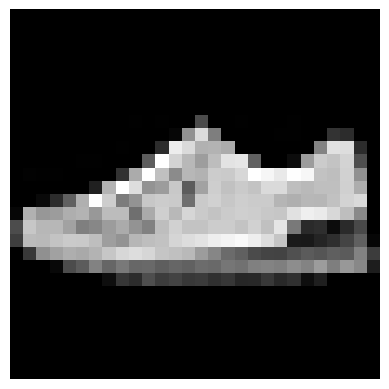

In [11]:
img = X_train[126]
print(one_hot_to_label(y_train[126]))
display_image(img)

## Create Train-Validation Set

In [12]:
def train_val_split(X, y, val_ratio, shuffle=True, seed=GLOBAL_SEED):
    N = len(X)
    indices = np.arange(N)

    np.random.seed(seed)
    if shuffle:
        np.random.shuffle(indices)

    val_size = int(N * val_ratio)

    val_idx = indices[:val_size]
    train_idx = indices[val_size:]

    return X[train_idx], y[train_idx], X[val_idx], y[val_idx]


In [ ]:
VAL_RATIO = 0.2
X_train, y_train, X_test, y_test = train_val_split(X_train, y_train, VAL_RATIO)

In [ ]:
print(X_train.shape)
print(X_test.shape)

(48000, 784)
(12000, 784)


In [15]:
INPUT_SIZE = X_train.shape[1]
VALIDATION_IDX = 666  # used to display one image from the validation set and its reconstruction

## Helper Functions

In [149]:
def test_with_PSNR(reconstructed_images, target_images, val_idx):    
    psnr_sum = 0
    for target_image, reconstructed_image in zip(target_images, reconstructed_images):
        psnr_sum += calculate_psnr(target_image, reconstructed_image)
    psnr_mean = psnr_sum / len(target_images)
    
    if val_idx == VALIDATION_IDX:
        print(f"Mean PSNR: {psnr_mean:8f}\n")
    
    # Display and compare one image and its respective reconstruction
    target_image = target_images[val_idx]
    reconstructed_image = reconstructed_images[val_idx]

    print(f"Sample image", end=' - ')
    print(f"PSNR: {calculate_psnr(target_image, reconstructed_image):6f}" )
    display_and_compare_images(img_original=target_image, img_reconstructed=reconstructed_image)
    
    return float(psnr_mean)

In [27]:
def get_model_predictions(model, vectorized_images):
    predictions = []
    for vector in vectorized_images:
        predictions.append(model.forward(vector))
    return np.array(predictions)

In [28]:
def train_autoencoder_model(model, X_train, X_val, epochs=50, batch_size=1):    
    # Train Autoencoder Model
    model.train(X_train, X_train, batch_size=batch_size,
                epochs=epochs, print_interval=math.ceil(epochs/10), 
                test_model=True, X_test=X_val, Y_test=X_val)

In [29]:
def evaluate_autoencoder_model(model, X_val):
    # Plot model's loss history
    print("Loss history over epochs:")
    plot_metric_over_epoch(model.train_loss_list, model.test_loss_list, val=True, title="Mean Loss over Epochs", figure_size=(6,4))
    
    # Reconstruct validation images from model prediction 
    val_predictions = get_model_predictions(model, X_val)
    val_predictions = val_predictions.reshape(-1, IMAGE_DIM, IMAGE_DIM)
    X_val = X_val.reshape(-1, IMAGE_DIM, IMAGE_DIM)
    
    # Evaluate image reconstructione by comparing them to the original image using the PSNR metric
    print("\nValidation data", end=' - ')
    val_psnr = test_with_PSNR(reconstructed_images=val_predictions, target_images=X_val, val_idx=VALIDATION_IDX)
    
    return val_psnr

In [30]:
# def plot_metric_over_epoch(train_metric_list, test_metric_list=None, val=False, title="", y_label="Mean Loss", figure_size=(8, 5)):
#     plt.figure(figsize=figure_size)

#     epochs = np.arange(1, len(train_metric_list) + 1)
#     plt.plot(epochs, train_metric_list, label='Train', linewidth=2)
#     if test_metric_list is not None:
#         label = 'Validation' if val else 'Test' 
#         plt.plot(epochs, test_metric_list, color='salmon', label=label, linewidth=2)

#     plt.xlabel('Epoch')
#     plt.ylabel(y_label)
#     plt.title(title)
#     plt.grid(True, linestyle="--", alpha=0.4)
#     plt.legend()
#     # plt.tight_layout()
#     plt.show()

## 3.1 Train Autoencoder

### 3.1.a Hidden Layer Neurons

In [21]:
lr = 0.001
epochs = 10
batch_size = 1

Model 1: Hidden layer size = 64

In [22]:
hidden_layer_size = 64

model_1 = MLP(
    layer_sizes=[INPUT_SIZE, hidden_layer_size, INPUT_SIZE],
    activations=[Sigmoid(), Sigmoid()],
    loss="mse",
    lr=lr,
    weight_type="xavier"
)

print(model_1)

Multi-Layer Perceptron Details:
Input Size: 784
Output Size: 784
Architecture:
  Layer  1: Linear Block (784, 64),   Activation: Sigmoid
  Layer  2: Linear Block (64, 784),   Activation: Sigmoid
Learning Rate: 0.001
Momentum: 0.0
Weight Initialization Type: xavier


In [ ]:
train_autoencoder_model(model_1, X_train, X_test, epochs, batch_size)

Training:   0%|          | 0/10 [00:00<?, ?Epoch/s]

Epoch    1 /   10,   Train Loss: 0.058422,   Test Loss: 0.041461
Epoch    2 /   10,   Train Loss: 0.034745,   Test Loss: 0.030633
Epoch    3 /   10,   Train Loss: 0.028274,   Test Loss: 0.026674
Epoch    4 /   10,   Train Loss: 0.025321,   Test Loss: 0.024389
Epoch    5 /   10,   Train Loss: 0.023471,   Test Loss: 0.022876
Epoch    6 /   10,   Train Loss: 0.022193,   Test Loss: 0.021780
Epoch    7 /   10,   Train Loss: 0.021219,   Test Loss: 0.020902
Epoch    8 /   10,   Train Loss: 0.020410,   Test Loss: 0.020153
Epoch    9 /   10,   Train Loss: 0.019707,   Test Loss: 0.019494
Epoch   10 /   10,   Train Loss: 0.019086,   Test Loss: 0.018910

Total training time: 4 min 31.979422 sec


Loss history over epochs:


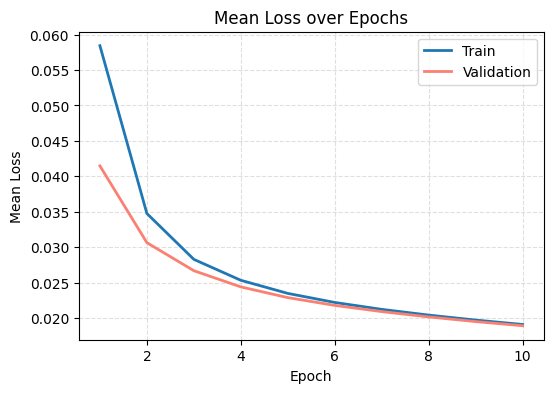


Validation data - Mean PSNR: 17.764995

Sample image - PSNR: 17.164848


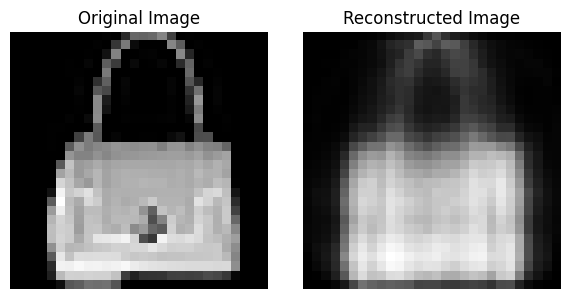

In [ ]:
psnr_1 = evaluate_autoencoder_model(model_1, X_test)

Model 2: Hidden layer size = 128

In [32]:
hidden_layer_size = 128

model_2 = MLP(
    layer_sizes=[INPUT_SIZE, hidden_layer_size, INPUT_SIZE],
    activations=[Sigmoid(), Sigmoid()],
    loss="mse",
    lr=lr,
    weight_type="xavier"
)

print(model_2)

Multi-Layer Perceptron Details:
Input Size: 784
Output Size: 784
Architecture:
  Layer  1: Linear Block (784, 128),   Activation: Sigmoid
  Layer  2: Linear Block (128, 784),   Activation: Sigmoid
Learning Rate: 0.001
Momentum: 0.0
Weight Initialization Type: xavier


In [ ]:
train_autoencoder_model(model_2, X_train, X_test, epochs, batch_size)

Training:   0%|          | 0/10 [00:00<?, ?Epoch/s]

Epoch    1 /   10,   Train Loss: 0.047074,   Test Loss: 0.031835
Epoch    2 /   10,   Train Loss: 0.027721,   Test Loss: 0.025132
Epoch    3 /   10,   Train Loss: 0.023380,   Test Loss: 0.022125
Epoch    4 /   10,   Train Loss: 0.021023,   Test Loss: 0.020226
Epoch    5 /   10,   Train Loss: 0.019395,   Test Loss: 0.018797
Epoch    6 /   10,   Train Loss: 0.018105,   Test Loss: 0.017628
Epoch    7 /   10,   Train Loss: 0.017044,   Test Loss: 0.016663
Epoch    8 /   10,   Train Loss: 0.016166,   Test Loss: 0.015862
Epoch    9 /   10,   Train Loss: 0.015431,   Test Loss: 0.015185
Epoch   10 /   10,   Train Loss: 0.014803,   Test Loss: 0.014601

Total training time: 12 min 38.916981 sec


Loss history over epochs:


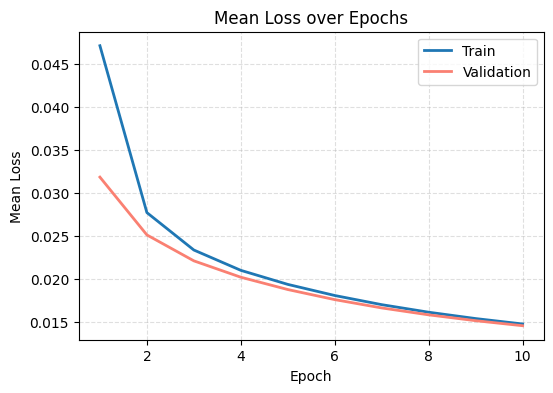


Validation data - Mean PSNR: 18.976234

Sample image - PSNR: 18.015070


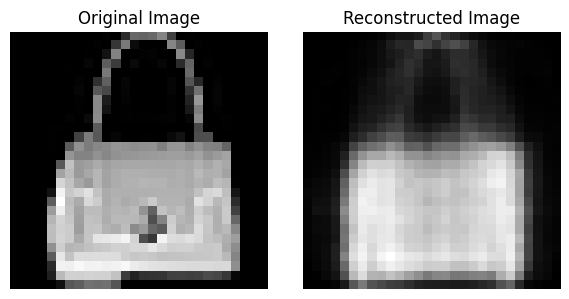

In [ ]:
psnr_2 = evaluate_autoencoder_model(model_2, X_test)

### 3.1.b Model Architecture

Due to the exteremly long training process, the number of training epochs is set to 5. Each model is trained twice in succession, for a total of 10 epochs.

The process would be significanly faster if we used a library such as PyTorch to run it on the GPU.

In [39]:
epochs = 5

Model 3: Architecture  768 - 256 - 64 - 256 - 768

In [40]:
model_3 = MLP(
    layer_sizes=[INPUT_SIZE, 256, 64, 256, INPUT_SIZE],
    activations=[Sigmoid(), Sigmoid(), Sigmoid(), Sigmoid()],
    loss="mse",
    lr=lr,
    weight_type="xavier"
)

print(model_3)

Multi-Layer Perceptron Details:
Input Size: 784
Output Size: 784
Architecture:
  Layer  1: Linear Block (784, 256),   Activation: Sigmoid
  Layer  2: Linear Block (256, 64),   Activation: Sigmoid
  Layer  3: Linear Block (64, 256),   Activation: Sigmoid
  Layer  4: Linear Block (256, 784),   Activation: Sigmoid
Learning Rate: 0.001
Momentum: 0.0
Weight Initialization Type: xavier


Epochs 1-5:

In [ ]:
train_autoencoder_model(model_3, X_train, X_test, epochs, batch_size)

Training:   0%|          | 0/5 [00:00<?, ?Epoch/s]

Epoch    1 /    5,   Train Loss: 0.065701,   Test Loss: 0.045739
Epoch    2 /    5,   Train Loss: 0.043301,   Test Loss: 0.041443
Epoch    3 /    5,   Train Loss: 0.039249,   Test Loss: 0.037284
Epoch    4 /    5,   Train Loss: 0.034507,   Test Loss: 0.032517
Epoch    5 /    5,   Train Loss: 0.030462,   Test Loss: 0.028895

Total training time: 32 min 16.129610 sec


Epcohs 6-10:

In [ ]:
train_autoencoder_model(model_3, X_train, X_test, epochs, batch_size)

Training:   0%|          | 0/5 [00:00<?, ?Epoch/s]

Epoch    1 /    5,   Train Loss: 0.027593,   Test Loss: 0.026681
Epoch    2 /    5,   Train Loss: 0.025838,   Test Loss: 0.025336
Epoch    3 /    5,   Train Loss: 0.024773,   Test Loss: 0.024440
Epoch    4 /    5,   Train Loss: 0.023979,   Test Loss: 0.023706
Epoch    5 /    5,   Train Loss: 0.023300,   Test Loss: 0.023067

Total training time: 31 min 36.055698 sec


Loss history over epochs:


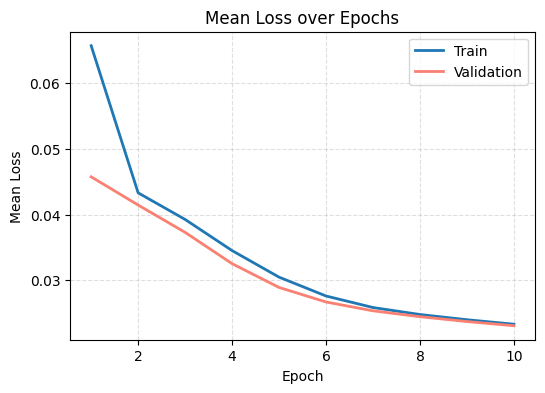


Validation data - Mean PSNR: 16.872900

Sample image - PSNR: 16.803726


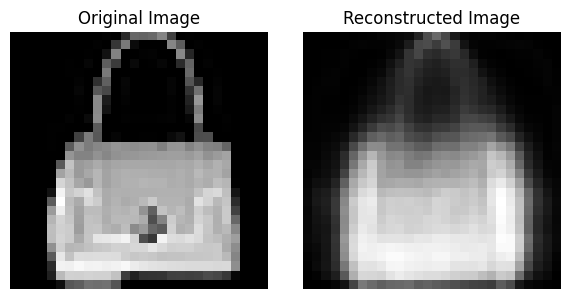

In [ ]:
psnr_3 = evaluate_autoencoder_model(model_3, X_test)

Model 4: Architecture  768 - 256 - 128 - 64 - 128 - 256 - 768

In [45]:
model_4 = MLP(
    layer_sizes=[INPUT_SIZE, 256, 128, 64, 128, 256, INPUT_SIZE],
    activations=[Sigmoid(), Sigmoid(), Sigmoid(), Sigmoid(), Sigmoid(), Sigmoid()],
    loss="mse",
    lr=lr,
    weight_type="xavier"
)

print(model_4)

Multi-Layer Perceptron Details:
Input Size: 784
Output Size: 784
Architecture:
  Layer  1: Linear Block (784, 256),   Activation: Sigmoid
  Layer  2: Linear Block (256, 128),   Activation: Sigmoid
  Layer  3: Linear Block (128, 64),   Activation: Sigmoid
  Layer  4: Linear Block (64, 128),   Activation: Sigmoid
  Layer  5: Linear Block (128, 256),   Activation: Sigmoid
  Layer  6: Linear Block (256, 784),   Activation: Sigmoid
Learning Rate: 0.001
Momentum: 0.0
Weight Initialization Type: xavier


Epoch 1-5:

In [ ]:
train_autoencoder_model(model_4, X_train, X_test, epochs, batch_size)

Training:   0%|          | 0/5 [00:00<?, ?Epoch/s]

Epoch    1 /    5,   Train Loss: 0.087418,   Test Loss: 0.087588
Epoch    2 /    5,   Train Loss: 0.087082,   Test Loss: 0.087556
Epoch    3 /    5,   Train Loss: 0.087013,   Test Loss: 0.087357
Epoch    4 /    5,   Train Loss: 0.069258,   Test Loss: 0.061703
Epoch    5 /    5,   Train Loss: 0.059379,   Test Loss: 0.057085

Total training time: 33 min 27.178951 sec


Epoch 6-10:

In [ ]:
train_autoencoder_model(model_4, X_train, X_test, epochs, batch_size)

Training:   0%|          | 0/5 [00:00<?, ?Epoch/s]

Epoch    1 /    5,   Train Loss: 0.046726,   Test Loss: 0.043323
Epoch    2 /    5,   Train Loss: 0.040448,   Test Loss: 0.038839
Epoch    3 /    5,   Train Loss: 0.037595,   Test Loss: 0.037077
Epoch    4 /    5,   Train Loss: 0.036271,   Test Loss: 0.035989
Epoch    5 /    5,   Train Loss: 0.035293,   Test Loss: 0.035103

Total training time: 34 min 57.856136 sec


Loss history over epochs:


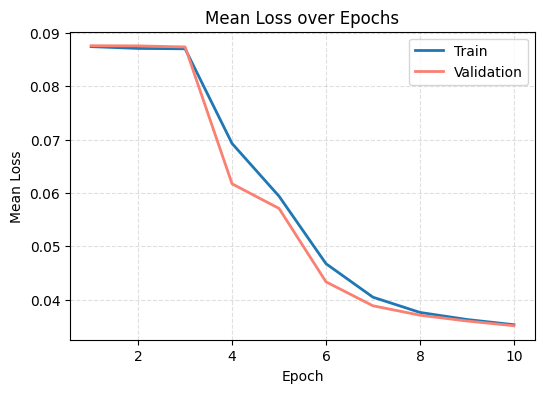


Validation data - Mean PSNR: 15.185058

Sample image - PSNR: 12.924865


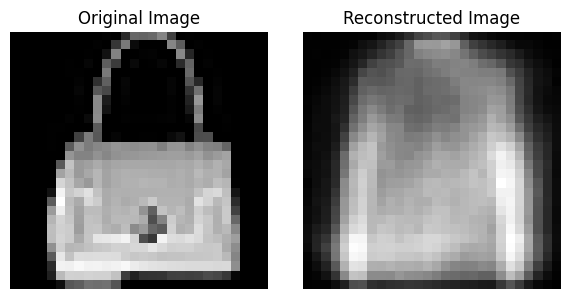

In [ ]:
psnr_4 = evaluate_autoencoder_model(model_4, X_test)

Comparison

In [54]:
print( 'Model Evaluation Summary:\n\n' +
       '         Model                  | Train Loss |  Val Loss  | Val PSNR\n' +
       '----------------------------------------------------------------------------\n' +
      f' H: 64                          |  {model_1.train_loss_list[-1]:6f}  |  {model_1.test_loss_list[-1]:6f}  | {psnr_1:6f}\n' +
      f' H: 128                         |  {model_2.train_loss_list[-1]:6f}  |  {model_2.test_loss_list[-1]:6f}  | {psnr_2:6f}\n' +
      f' H: 256 - 64 - 256              |  {model_3.train_loss_list[-1]:6f}  |  {model_3.test_loss_list[-1]:6f}  | {psnr_3:6f}\n' +
      f' H: 256 - 128 - 64 - 128 - 256  |  {model_4.train_loss_list[-1]:6f}  |  {model_4.test_loss_list[-1]:6f}  | {psnr_4:6f}')

Model Evaluation Summary:

         Model                  | Train Loss |  Val Loss  | Val PSNR
----------------------------------------------------------------------------
 H: 64                          |  0.019086  |  0.018910  | 17.764995
 H: 128                         |  0.014803  |  0.014601  | 18.976234
 H: 256 - 64 - 256              |  0.023300  |  0.023067  | 16.872900
 H: 256 - 128 - 64 - 128 - 256  |  0.035293  |  0.035103  | 15.185058


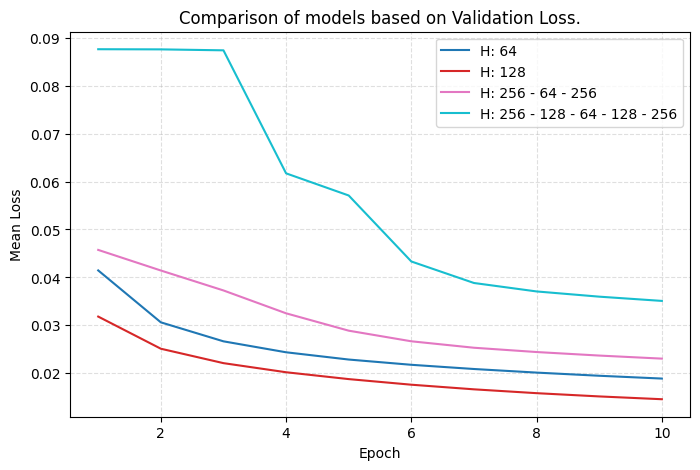

In [55]:
plot_train_metrics([model_1.test_loss_list, model_2.test_loss_list, model_3.test_loss_list, model_4.test_loss_list],
                    labels=['H: 64', 'H: 128', 'H: 256 - 64 - 256', 'H: 256 - 128 - 64 - 128 - 256'],
                    title="Comparison of models based on Validation Loss.",
                    figure_size=(8, 5))

Best Architecture: 

In [56]:
best_layer_sizes = [INPUT_SIZE, 128, INPUT_SIZE]

### 3.1.c ReLU

In [57]:
epochs = 10

In [58]:
model_5 = MLP(
    layer_sizes=best_layer_sizes,
    activations=[ReLU() for _ in range(len(best_layer_sizes)-1)],
    loss="mse",
    lr=lr,
    weight_type="xavier"
)

print(model_5)

Multi-Layer Perceptron Details:
Input Size: 784
Output Size: 784
Architecture:
  Layer  1: Linear Block (784, 128),   Activation: ReLU
  Layer  2: Linear Block (128, 784),   Activation: ReLU
Learning Rate: 0.001
Momentum: 0.0
Weight Initialization Type: xavier


In [ ]:
train_autoencoder_model(model_5, X_train, X_test, epochs, batch_size)

Training:   0%|          | 0/10 [00:00<?, ?Epoch/s]

Epoch    1 /   10,   Train Loss: 0.028578,   Test Loss: 0.020525
Epoch    2 /   10,   Train Loss: 0.017944,   Test Loss: 0.016881
Epoch    3 /   10,   Train Loss: 0.016049,   Test Loss: 0.015693
Epoch    4 /   10,   Train Loss: 0.014971,   Test Loss: 0.014692
Epoch    5 /   10,   Train Loss: 0.014267,   Test Loss: 0.014305
Epoch    6 /   10,   Train Loss: 0.013950,   Test Loss: 0.014073
Epoch    7 /   10,   Train Loss: 0.013751,   Test Loss: 0.013882
Epoch    8 /   10,   Train Loss: 0.013556,   Test Loss: 0.013548
Epoch    9 /   10,   Train Loss: 0.013272,   Test Loss: 0.013425
Epoch   10 /   10,   Train Loss: 0.013177,   Test Loss: 0.013335

Total training time: 10 min 20.098300 sec


Loss history over epochs:


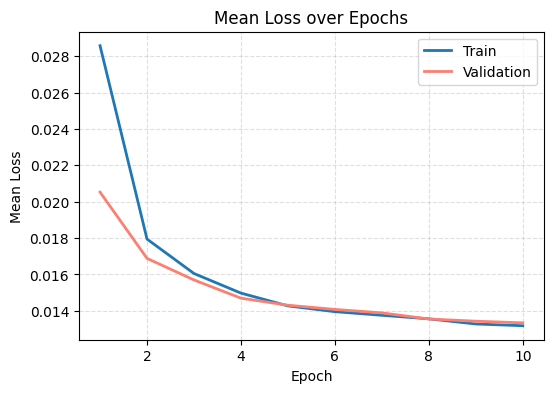


Validation data - Mean PSNR: 19.506506

Sample image - PSNR: 18.904370


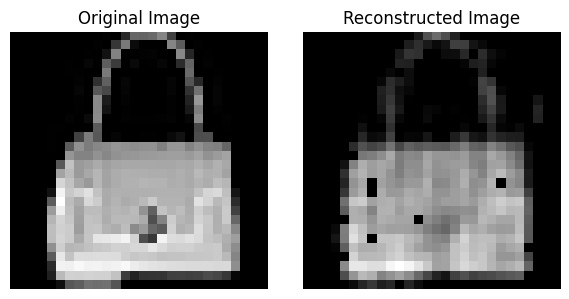

In [ ]:
psnr_5 = evaluate_autoencoder_model(model_5, X_test)

Comparison:

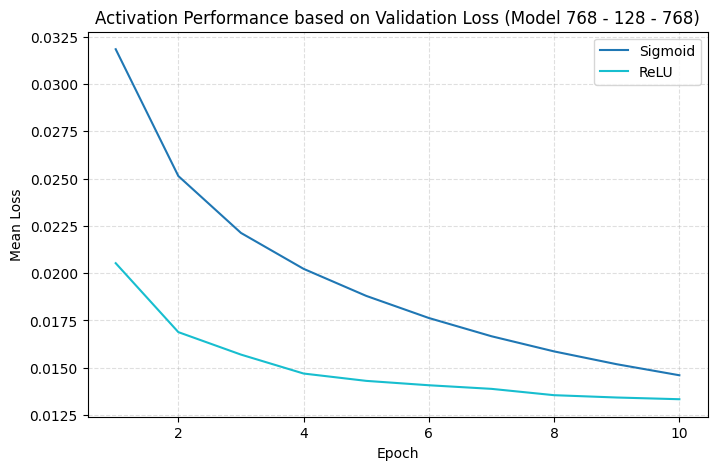

In [69]:
plot_train_metrics([model_2.test_loss_list, model_5.test_loss_list],
                    labels=['Sigmoid', 'ReLU'],
                    title="Activation Performance based on Validation Loss (Model 768 - 128 - 768)",
                    figure_size=(8, 5))

ReLU perform better than signoid:

In [62]:
best_activations = [ReLU() for _ in range(len(best_layer_sizes)-1)]

### 3.1.d Learning Rate

Learning rate = 0.01

In [63]:
lr = 0.01

model_6 = MLP(
    layer_sizes=best_layer_sizes,
    activations=best_activations,
    loss="mse",
    lr=lr,
    weight_type="xavier"
)

print(model_6)

Multi-Layer Perceptron Details:
Input Size: 784
Output Size: 784
Architecture:
  Layer  1: Linear Block (784, 128),   Activation: ReLU
  Layer  2: Linear Block (128, 784),   Activation: ReLU
Learning Rate: 0.01
Momentum: 0.0
Weight Initialization Type: xavier


In [ ]:
train_autoencoder_model(model_6, X_train, X_test, epochs, batch_size)

Training:   0%|          | 0/10 [00:00<?, ?Epoch/s]

Epoch    1 /   10,   Train Loss: 0.074885,   Test Loss: 0.078109
Epoch    2 /   10,   Train Loss: 0.078854,   Test Loss: 0.083390
Epoch    3 /   10,   Train Loss: 0.078573,   Test Loss: 0.085789
Epoch    4 /   10,   Train Loss: 0.080883,   Test Loss: 0.084081
Epoch    5 /   10,   Train Loss: 0.081425,   Test Loss: 0.080797
Epoch    6 /   10,   Train Loss: 0.081524,   Test Loss: 0.082908
Epoch    7 /   10,   Train Loss: 0.082610,   Test Loss: 0.086800
Epoch    8 /   10,   Train Loss: 0.082134,   Test Loss: 0.083113
Epoch    9 /   10,   Train Loss: 0.082819,   Test Loss: 0.084049
Epoch   10 /   10,   Train Loss: 0.082783,   Test Loss: 0.083188

Total training time: 10 min 1.939541 sec


Loss history over epochs:


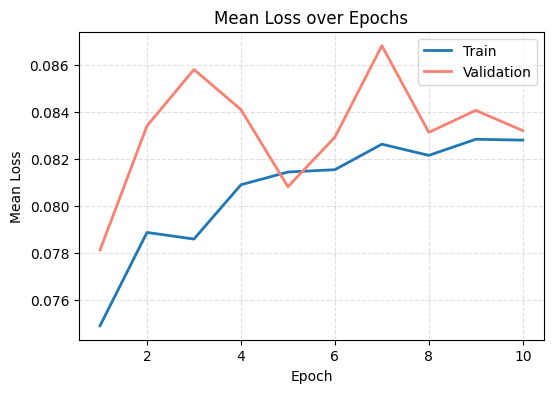


Validation data - Mean PSNR: 11.136798

Sample image - PSNR: 10.992744


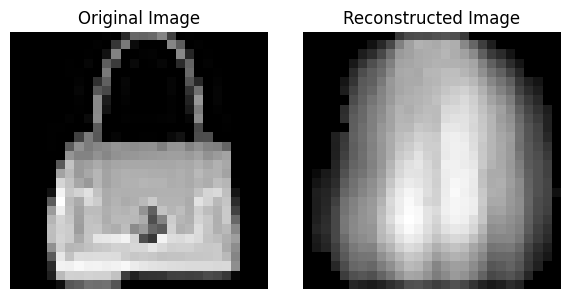

In [ ]:
psnr_6 = evaluate_autoencoder_model(model_6, X_test)

Learning Rate = 0.000001

In [66]:
lr = 0.000001

model_7 = MLP(
    layer_sizes=best_layer_sizes,
    activations=best_activations,
    loss="mse",
    lr=lr,
    weight_type="xavier"
)

print(model_7)

Multi-Layer Perceptron Details:
Input Size: 784
Output Size: 784
Architecture:
  Layer  1: Linear Block (784, 128),   Activation: ReLU
  Layer  2: Linear Block (128, 784),   Activation: ReLU
Learning Rate: 1e-06
Momentum: 0.0
Weight Initialization Type: xavier


In [ ]:
train_autoencoder_model(model_7, X_train, X_test, epochs, batch_size)

Training:   0%|          | 0/10 [00:00<?, ?Epoch/s]

Epoch    1 /   10,   Train Loss: 0.134464,   Test Loss: 0.109013
Epoch    2 /   10,   Train Loss: 0.102532,   Test Loss: 0.099171
Epoch    3 /   10,   Train Loss: 0.095482,   Test Loss: 0.093978
Epoch    4 /   10,   Train Loss: 0.091225,   Test Loss: 0.089655
Epoch    5 /   10,   Train Loss: 0.087390,   Test Loss: 0.086191
Epoch    6 /   10,   Train Loss: 0.083540,   Test Loss: 0.082233
Epoch    7 /   10,   Train Loss: 0.080326,   Test Loss: 0.079724
Epoch    8 /   10,   Train Loss: 0.077908,   Test Loss: 0.077135
Epoch    9 /   10,   Train Loss: 0.075706,   Test Loss: 0.075252
Epoch   10 /   10,   Train Loss: 0.073911,   Test Loss: 0.073391

Total training time: 9 min 9.194048 sec


Loss history over epochs:


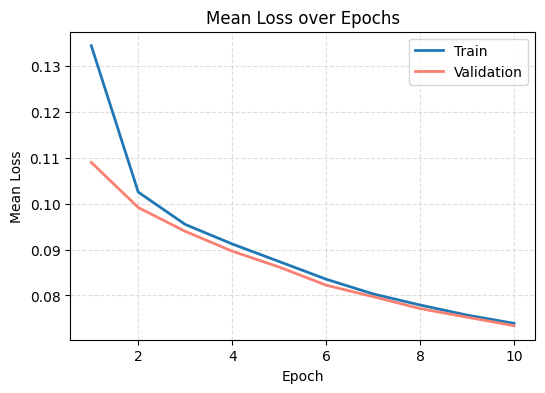


Validation data - Mean PSNR: 11.873826

Sample image - PSNR: 10.443992


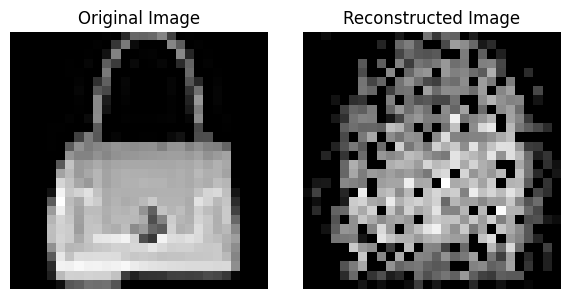

In [ ]:
psnr_7 = evaluate_autoencoder_model(model_7, X_test)

Comparison:

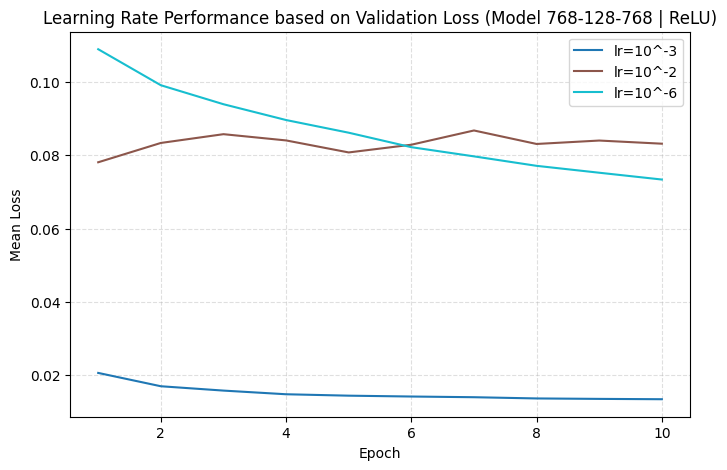

In [70]:
plot_train_metrics([model_5.test_loss_list, model_6.test_loss_list, model_7.test_loss_list],
                    labels=['lr=10^-3', 'lr=10^-2', 'lr=10^-6'],
                    title="Learning Rate Performance based on Validation Loss (Model 768-128-768 | ReLU)",
                    figure_size=(8, 5))

Best Learning Rate:

In [71]:
lr = 0.001

### 3.1.e Batch Gradient Descent

Batch Size = 8

In [72]:
batch_size = 8

model_8 = MLP(
    layer_sizes=best_layer_sizes,
    activations=best_activations,
    loss="mse",
    lr=lr,
    weight_type="xavier"
)

print(model_8)

Multi-Layer Perceptron Details:
Input Size: 784
Output Size: 784
Architecture:
  Layer  1: Linear Block (784, 128),   Activation: ReLU
  Layer  2: Linear Block (128, 784),   Activation: ReLU
Learning Rate: 0.001
Momentum: 0.0
Weight Initialization Type: xavier


In [ ]:
train_autoencoder_model(model_8, X_train, X_test, epochs, batch_size)

Training:   0%|          | 0/10 [00:00<?, ?Epoch/s]

Epoch    1 /   10,   Train Loss: 0.053578,   Test Loss: 0.041784
Epoch    2 /   10,   Train Loss: 0.038666,   Test Loss: 0.035211
Epoch    3 /   10,   Train Loss: 0.033011,   Test Loss: 0.031524
Epoch    4 /   10,   Train Loss: 0.030386,   Test Loss: 0.029928
Epoch    5 /   10,   Train Loss: 0.029056,   Test Loss: 0.028589
Epoch    6 /   10,   Train Loss: 0.027659,   Test Loss: 0.027226
Epoch    7 /   10,   Train Loss: 0.026720,   Test Loss: 0.026448
Epoch    8 /   10,   Train Loss: 0.025758,   Test Loss: 0.025425
Epoch    9 /   10,   Train Loss: 0.025108,   Test Loss: 0.025122
Epoch   10 /   10,   Train Loss: 0.024578,   Test Loss: 0.024346

Total training time: 4 min 45.911808 sec


Loss history over epochs:


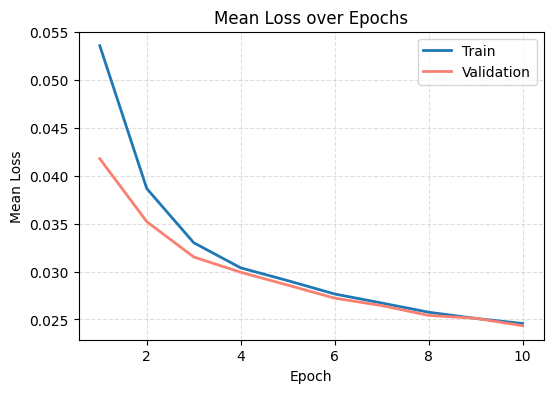


Validation data - Mean PSNR: 16.875466

Sample image - PSNR: 16.222771


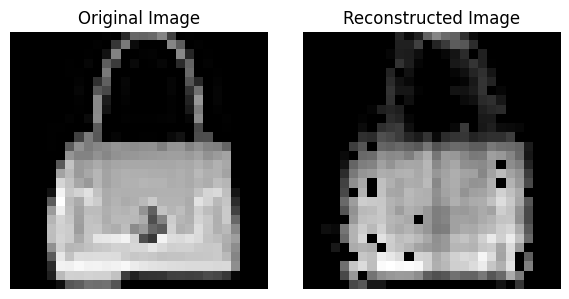

In [ ]:
psnr_8 = evaluate_autoencoder_model(model_8, X_test)

Batch Size = 16

In [75]:
batch_size = 16

model_9 = MLP(
    layer_sizes=best_layer_sizes,
    activations=best_activations,
    loss="mse",
    lr=lr,
    weight_type="xavier"
)

print(model_9)

Multi-Layer Perceptron Details:
Input Size: 784
Output Size: 784
Architecture:
  Layer  1: Linear Block (784, 128),   Activation: ReLU
  Layer  2: Linear Block (128, 784),   Activation: ReLU
Learning Rate: 0.001
Momentum: 0.0
Weight Initialization Type: xavier


In [ ]:
train_autoencoder_model(model_9, X_train, X_test, epochs, batch_size)

Training:   0%|          | 0/10 [00:00<?, ?Epoch/s]

Epoch    1 /   10,   Train Loss: 0.062086,   Test Loss: 0.048966
Epoch    2 /   10,   Train Loss: 0.045254,   Test Loss: 0.042408
Epoch    3 /   10,   Train Loss: 0.040966,   Test Loss: 0.039786
Epoch    4 /   10,   Train Loss: 0.038124,   Test Loss: 0.037271
Epoch    5 /   10,   Train Loss: 0.036141,   Test Loss: 0.035096
Epoch    6 /   10,   Train Loss: 0.033758,   Test Loss: 0.032935
Epoch    7 /   10,   Train Loss: 0.032120,   Test Loss: 0.031628
Epoch    8 /   10,   Train Loss: 0.031150,   Test Loss: 0.031066
Epoch    9 /   10,   Train Loss: 0.030666,   Test Loss: 0.030636
Epoch   10 /   10,   Train Loss: 0.030262,   Test Loss: 0.030234

Total training time: 4 min 13.129241 sec


Loss history over epochs:


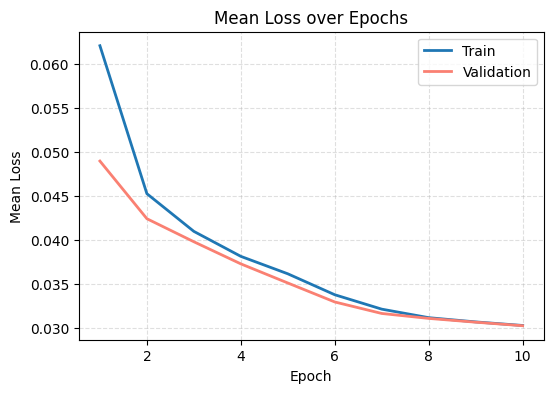


Validation data - Mean PSNR: 15.855673

Sample image - PSNR: 15.370047


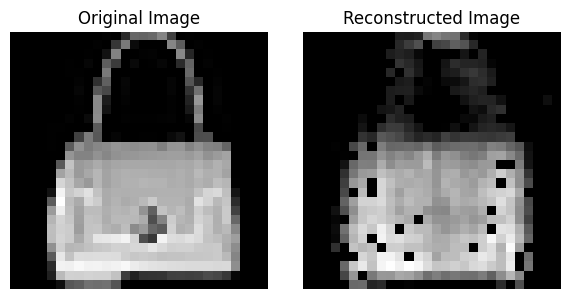

In [ ]:
psnr_9 = evaluate_autoencoder_model(model_9, X_test)

Comparison:

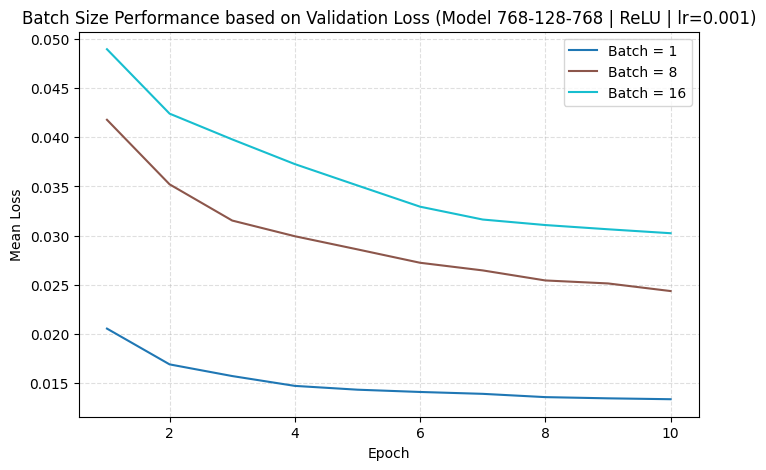

In [78]:
plot_train_metrics([model_5.test_loss_list, model_8.test_loss_list, model_9.test_loss_list],
                    labels=['Batch = 1', 'Batch = 8', 'Batch = 16'],
                    title="Batch Size Performance based on Validation Loss (Model 768-128-768 | ReLU | lr=0.001)",
                    figure_size=(8, 5))

### Best Model

Train the the best model to see if results improve.

In [89]:
print(f'Mean PSNR        10 epochs     {psnr_5}')
print(f'Mean Val Loss    10 epochs     {model_5.test_loss_list[-1]}')

Mean PSNR        10 epochs     19.506505709198443
Mean Val Loss    10 epochs     0.013334600798193529


In [ ]:
epochs = 10
train_autoencoder_model(model_5, X_train, X_test, epochs, batch_size)

Training:   0%|          | 0/10 [00:00<?, ?Epoch/s]

Epoch    1 /   10,   Train Loss: 0.012702,   Test Loss: 0.012815
Epoch    2 /   10,   Train Loss: 0.012670,   Test Loss: 0.012797
Epoch    3 /   10,   Train Loss: 0.012656,   Test Loss: 0.012785
Epoch    4 /   10,   Train Loss: 0.012644,   Test Loss: 0.012775
Epoch    5 /   10,   Train Loss: 0.012635,   Test Loss: 0.012766
Epoch    6 /   10,   Train Loss: 0.012626,   Test Loss: 0.012757
Epoch    7 /   10,   Train Loss: 0.012617,   Test Loss: 0.012749
Epoch    8 /   10,   Train Loss: 0.012609,   Test Loss: 0.012742
Epoch    9 /   10,   Train Loss: 0.012601,   Test Loss: 0.012734
Epoch   10 /   10,   Train Loss: 0.012594,   Test Loss: 0.012727

Total training time: 4 min 29.173829 sec


Test the model on the test data:

Loss history over epochs:


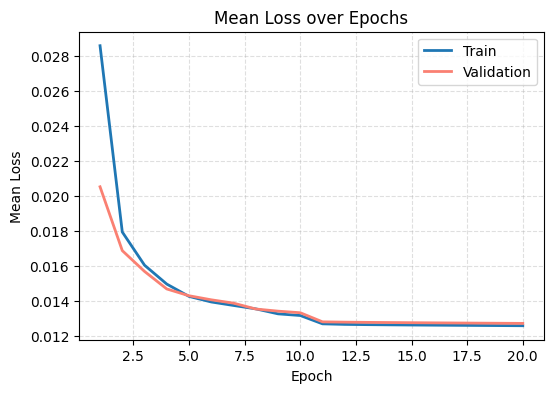


Validation data - Mean PSNR: 19.779051

Sample image - PSNR: 16.915799


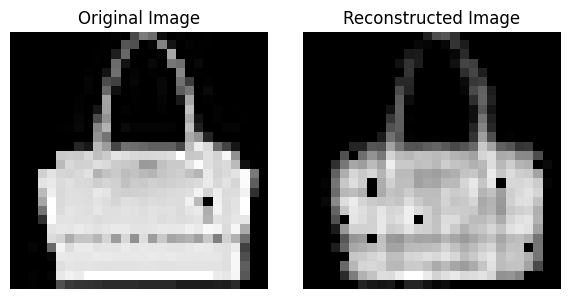

In [92]:
evaluate_autoencoder_model(model_5, X_train)

### 3.1.f Images with the largest and smallest Loss

In [136]:
# Reconstruct validation images from model prediction 
test_predictions = get_model_predictions(model_5, X_test)

loss_list = []
for y_true, y_pred in zip(X_test, test_predictions):
    loss_list.append(model_5.loss_fn.loss(y_true, y_pred))

loss_list = np.array(loss_list)
print(loss_list.shape)

(10000,)


In [ ]:
# Indices of smallest 5 values
smallest_idx = np.argsort(loss_list)[:5]

# Indices of largest 5 values
largest_idx = np.argsort(loss_list)[-5:]


Images with the smallest loss:

Loss: 0.001294816909676492
Sample image - PSNR: 28.877916


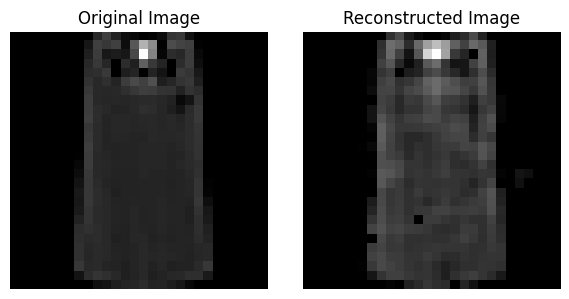

Loss: 0.001324065667216372
Sample image - PSNR: 28.780905


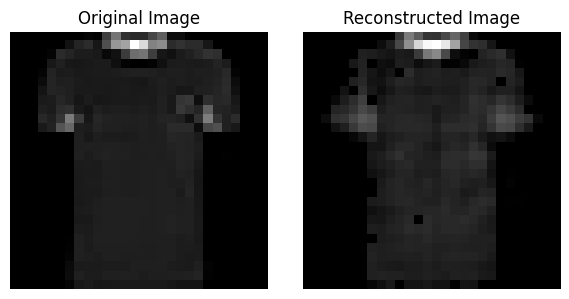

Loss: 0.0013378030347974282
Sample image - PSNR: 28.736078


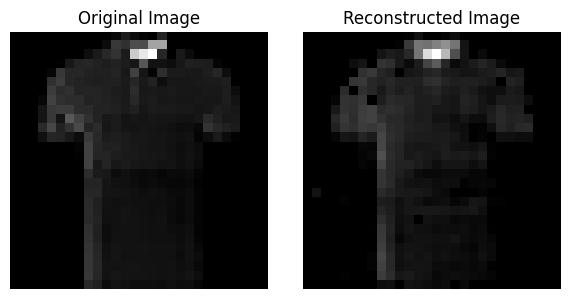

Loss: 0.0014019128264925762
Sample image - PSNR: 28.532790


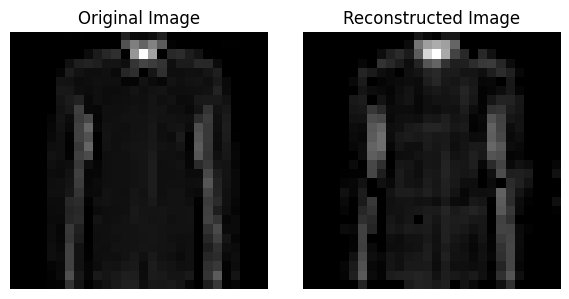

Loss: 0.0014666057931056208
Sample image - PSNR: 28.336866


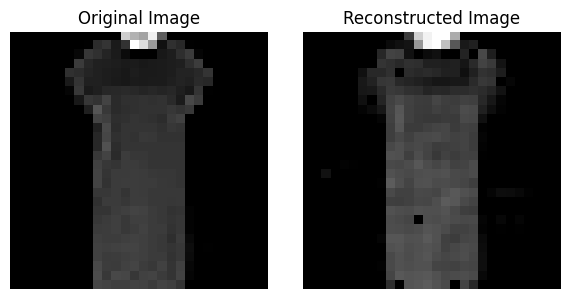

In [152]:
print("Images with the smallest loss:\n")
test_predictions = test_predictions.reshape(-1, IMAGE_DIM, IMAGE_DIM)
for idx in smallest_idx:
    print(f"Loss: {loss_list[idx]}")
    test_with_PSNR(reconstructed_images=test_predictions, target_images=test_images, val_idx=idx)

Images with the largest loss:

Loss: 0.07257164793131061
Sample image - PSNR: 11.392330


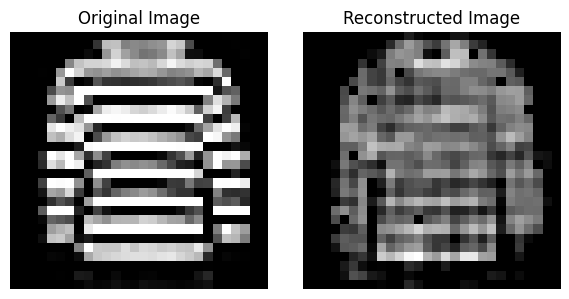

Loss: 0.07518172453436406
Sample image - PSNR: 11.238877


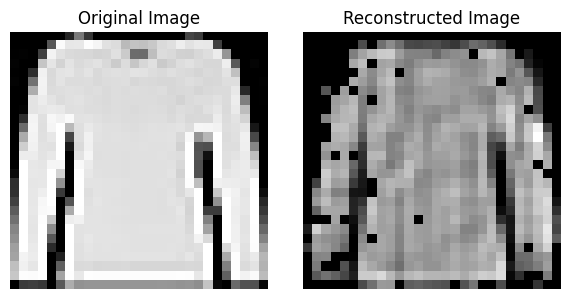

Loss: 0.07963199021472847
Sample image - PSNR: 10.989124


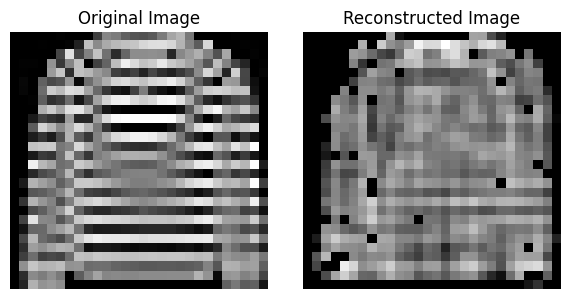

Loss: 0.08844603122716171
Sample image - PSNR: 10.533217


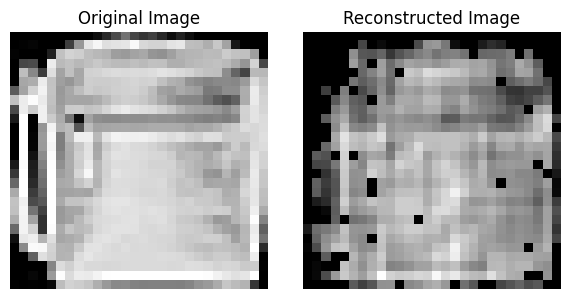

Loss: 0.09548767273210565
Sample image - PSNR: 10.200527


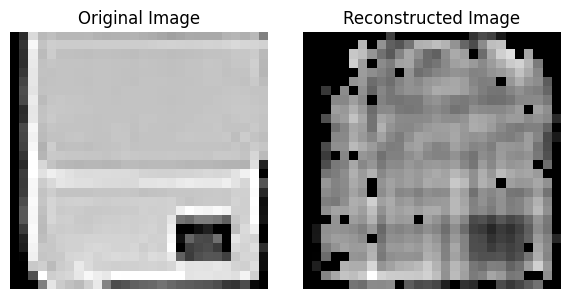

In [153]:
print("Images with the largest loss:\n")
test_predictions = test_predictions.reshape(-1, IMAGE_DIM, IMAGE_DIM)
for idx in largest_idx:
    print(f"Loss: {loss_list[idx]}")
    test_with_PSNR(reconstructed_images=test_predictions, target_images=test_images, val_idx=idx)

## 3.2 Train Classifier

### Helper Functions (Classification)

In [108]:
def train_classifier_model(classifier, feature_extractor, X_train, y_train, X_test, y_test, epochs=50, batch_size=1):    
    features_train = get_model_predictions(feature_extractor, X_train)
    features_test = get_model_predictions(feature_extractor, X_test)
    
    classifier.train(features_train, y_train, batch_size=batch_size,
                epochs=epochs, print_interval=math.ceil(epochs/10), 
                test_model=True, X_test=features_test, Y_test=y_test)

In [161]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

def evaluate_classifier_model(classifier, feature_extractor, X_test, y_test):
    # # Plot model's loss history
    print("Loss history over epochs:")
    plot_metric_over_epoch(classifier.train_loss_list, classifier.test_loss_list, title="Mean Loss over Epochs", figure_size=(6,4))
    
    # Make predictions about the test data
    features_test = get_model_predictions(feature_extractor, X_test)
    test_predictions = get_model_predictions(classifier, features_test)

    true_labels = np.argmax(y_test, axis=1)
    pred_labels = np.argmax(test_predictions, axis=1)
    
    # Metrics
    acc  = accuracy_score(true_labels, pred_labels)
    prec = precision_score(true_labels, pred_labels, average='macro')
    rec  = recall_score(true_labels, pred_labels, average='macro')
    f1   = f1_score(true_labels, pred_labels, average='macro')
    cm   = confusion_matrix(true_labels, pred_labels)

    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("F1-score:", f1)

    # Plot confusion matrix
    plt.figure(figsize=(6, 5))
    plt.imshow(cm, interpolation='nearest', cmap="YlOrRd")
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    
    plt.xticks(ticks=np.arange(cm.shape[1]), labels=np.arange(cm.shape[1]))
    plt.yticks(ticks=np.arange(cm.shape[0]), labels=np.arange(cm.shape[0]))


    # Add numbers inside cells
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j], ha="center", va="center")

    plt.tight_layout()
    plt.show()

Concatenate train and validation data:

In [ ]:
X_train_classifier = np.concatenate([X_train, X_test])
y_train_classifier = np.concatenate([y_train, y_test])

print(X_train_classifier.shape)
print(y_train_classifier.shape)

(60000, 784)
(60000, 10)


### 3.2.a Classifiers

Build feature extractor from the best autoencoder model - the latent layer is the output of the model.

The feature extractor is not trained here - it is only used to extract features based on its previous parameters.

In [ ]:
feature_extractor = MLP(
    layer_sizes=[],
    activations=[],
    existing_layers=model_5.layers[:1]
)

print(feature_extractor)

Multi-Layer Perceptron Details:
Input Size: 784
Output Size: 128
Architecture:
  Layer  1: Linear Block (784, 128),   Activation: ReLU
Learning Rate: 0.01
Momentum: 0.0
Weight Initialization Type: xavier


In [123]:
epochs = 50
lr = 0.001
batch_size = 8

**Classifier 1: 128 - 64 - 10**

In [127]:
classifier_1 = MLP(
    layer_sizes=[128, 64, 10],
    activations=[ReLU(),  Softmax()],
    loss="cross_entropy",
    lr=lr,
    weight_type="xavier"
)

print(classifier_1)

Multi-Layer Perceptron Details:
Input Size: 128
Output Size: 10
Architecture:
  Layer  1: Linear Block (128, 64),   Activation: ReLU
  Layer  2: Linear Block (64, 10),   Activation: Softmax
Learning Rate: 0.001
Momentum: 0.0
Weight Initialization Type: xavier


In [128]:
train_classifier_model(classifier_1, feature_extractor, 
                       X_train=X_train_classifier, y_train=y_train_classifier,
                       X_test=X_test, y_test=y_test,
                       epochs=epochs, batch_size=batch_size)   

Training:   0%|          | 0/50 [00:00<?, ?Epoch/s]

Epoch    5 /   50,   Train Loss: 0.529821,   Test Loss: 0.542132
Epoch   10 /   50,   Train Loss: 0.475412,   Test Loss: 0.500697
Epoch   15 /   50,   Train Loss: 0.453287,   Test Loss: 0.483123
Epoch   20 /   50,   Train Loss: 0.439182,   Test Loss: 0.471615
Epoch   25 /   50,   Train Loss: 0.427859,   Test Loss: 0.462448
Epoch   30 /   50,   Train Loss: 0.417527,   Test Loss: 0.453890
Epoch   35 /   50,   Train Loss: 0.408006,   Test Loss: 0.445867
Epoch   40 /   50,   Train Loss: 0.399397,   Test Loss: 0.438429
Epoch   45 /   50,   Train Loss: 0.391757,   Test Loss: 0.431923
Epoch   50 /   50,   Train Loss: 0.384855,   Test Loss: 0.426076

Total training time: 4 min 55.160653 sec


Loss history over epochs:


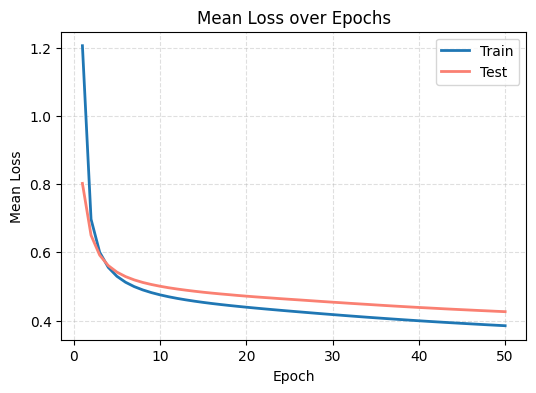

Accuracy: 0.8503
Precision: 0.8490009400935437
Recall: 0.8503000000000001
F1-score: 0.8492294763638686


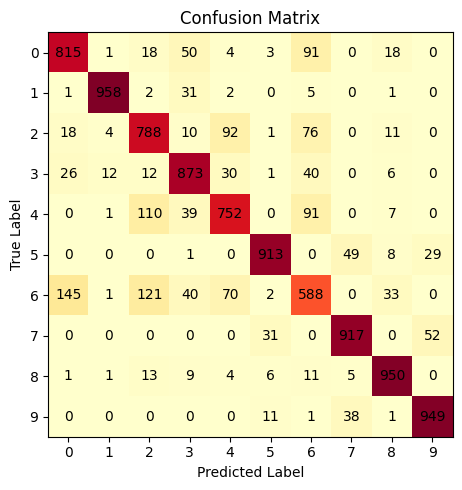

In [162]:
evaluate_classifier_model(classifier_1, feature_extractor, X_test, y_test)

**Classifier 2: 128 - 32 - 10**

In [124]:
classifier_2 = MLP(
    layer_sizes=[128, 32, 10],
    activations=[ReLU(),  Softmax()],
    loss="cross_entropy",
    lr=lr,
    weight_type="xavier"
)

print(classifier_2)

Multi-Layer Perceptron Details:
Input Size: 128
Output Size: 10
Architecture:
  Layer  1: Linear Block (128, 32),   Activation: ReLU
  Layer  2: Linear Block (32, 10),   Activation: Softmax
Learning Rate: 0.001
Momentum: 0.0
Weight Initialization Type: xavier


In [125]:
train_classifier_model(classifier_2, feature_extractor, 
                       X_train=X_train_classifier, y_train=y_train_classifier,
                       X_test=X_test, y_test=y_test,
                       epochs=epochs, batch_size=batch_size)   

Training:   0%|          | 0/50 [00:00<?, ?Epoch/s]

Epoch    5 /   50,   Train Loss: 0.546474,   Test Loss: 0.557021
Epoch   10 /   50,   Train Loss: 0.485137,   Test Loss: 0.509328
Epoch   15 /   50,   Train Loss: 0.460015,   Test Loss: 0.489483
Epoch   20 /   50,   Train Loss: 0.444973,   Test Loss: 0.477429
Epoch   25 /   50,   Train Loss: 0.434217,   Test Loss: 0.468584
Epoch   30 /   50,   Train Loss: 0.425530,   Test Loss: 0.461455
Epoch   35 /   50,   Train Loss: 0.418294,   Test Loss: 0.455194
Epoch   40 /   50,   Train Loss: 0.412032,   Test Loss: 0.449898
Epoch   45 /   50,   Train Loss: 0.406594,   Test Loss: 0.445334
Epoch   50 /   50,   Train Loss: 0.401681,   Test Loss: 0.441260

Total training time: 3 min 31.459350 sec


Loss history over epochs:


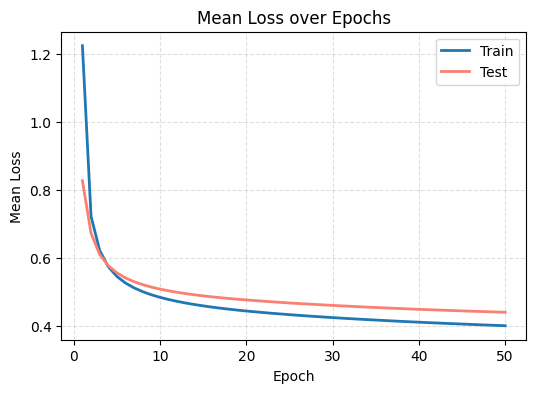

Accuracy: 0.8482
Precision: 0.846201576004083
Recall: 0.8482
F1-score: 0.8464931148198025


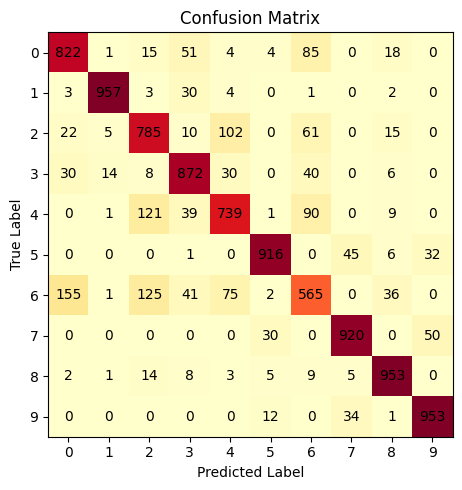

In [163]:
evaluate_classifier_model(classifier_2, feature_extractor, X_test, y_test)

In [175]:
print( 'Model Evaluation Summary:\n\n' +
       '      Model     | Train Loss |  Test Loss | Accuracy\n' +
       '-------------------------------------------------------\n' +
      f' 128 - 64 - 10  |  {classifier_1.train_loss_list[-1]:6f}  |  {classifier_1.test_loss_list[-1]:6f}  |  0.8503\n' +
      f' 128 - 32 - 10  |  {classifier_2.train_loss_list[-1]:6f}  |  {classifier_2.test_loss_list[-1]:6f}  |  0.8482')

Model Evaluation Summary:

      Model     | Train Loss |  Test Loss | Accuracy
-------------------------------------------------------
 128 - 64 - 10  |  0.384855  |  0.426076  |  0.8503
 128 - 32 - 10  |  0.401681  |  0.441260  |  0.8482


### Sample Classification:

In [ ]:
def classify(classifier, idx):
    features = get_model_predictions(feature_extractor, [X_test[idx]])
    test_predictions = get_model_predictions(classifier, [features[0]])

    print(f"True label: {one_hot_to_label(y_test[idx])}")
    print(f"Predicted label: {one_hot_to_label(test_predictions[0])}")

    display_image(X_test[idx])

True label: Dress
Predicted label: Dress


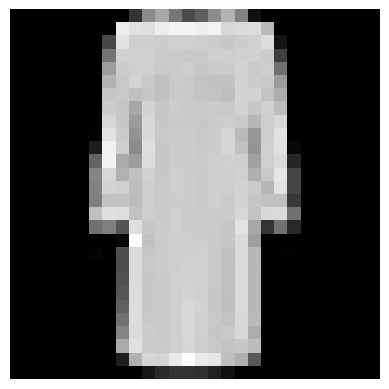

In [ ]:
classify(classifier_2, 1807)

True label: T-shirt/top
Predicted label: Shirt


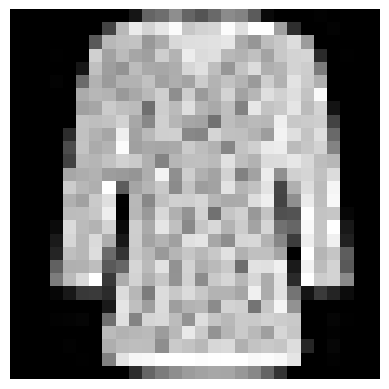

In [ ]:
classify(classifier_1, 1867)